In [35]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## Read data as a pandas DataFrame 


In [8]:
path = 'data/stud.csv'

df = pd.read_csv(path)

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### show number of rows and columns in the dataset

In [9]:
df.shape

(1000, 8)

#### show columns names

In [10]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

#### show number of missing values

In [11]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [50]:
df.duplicated().sum()

0

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [15]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [19]:
numeric_df = df.select_dtypes(include=np.number)
cat_df = df.select_dtypes(include='object')


In [20]:
numeric_df.head(2)

,math_score,reading_score,writing_score
0,72,72,74
1,69,90,88


In [21]:
cat_df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course
0,female,group B,bachelor's degree,standard,none
1,female,group C,some college,standard,completed


In [24]:
for col in cat_df.columns:
    print(f"{col}: {cat_df[col].unique()}")
    print(f"Number of unique values: {cat_df[col].nunique()}")
    print("-"*50)

gender: ['female' 'male']
Number of unique values: 2
--------------------------------------------------
race_ethnicity: ['group B' 'group C' 'group A' 'group D' 'group E']
Number of unique values: 5
--------------------------------------------------
parental_level_of_education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Number of unique values: 6
--------------------------------------------------
lunch: ['standard' 'free/reduced']
Number of unique values: 2
--------------------------------------------------
test_preparation_course: ['none' 'completed']
Number of unique values: 2
--------------------------------------------------


In [25]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [26]:
df.describe(include='object')

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


In [51]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score'] / 3

df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [55]:
numeric_df['total_score'] = df['total_score']
numeric_df['average'] = df['average']

In [56]:
numeric_df.head(2)

,math_score,reading_score,writing_score,total_score,average
0,72,72,74,218,72.666667
1,69,90,88,247,82.333333


## EDA 

#### cat bars

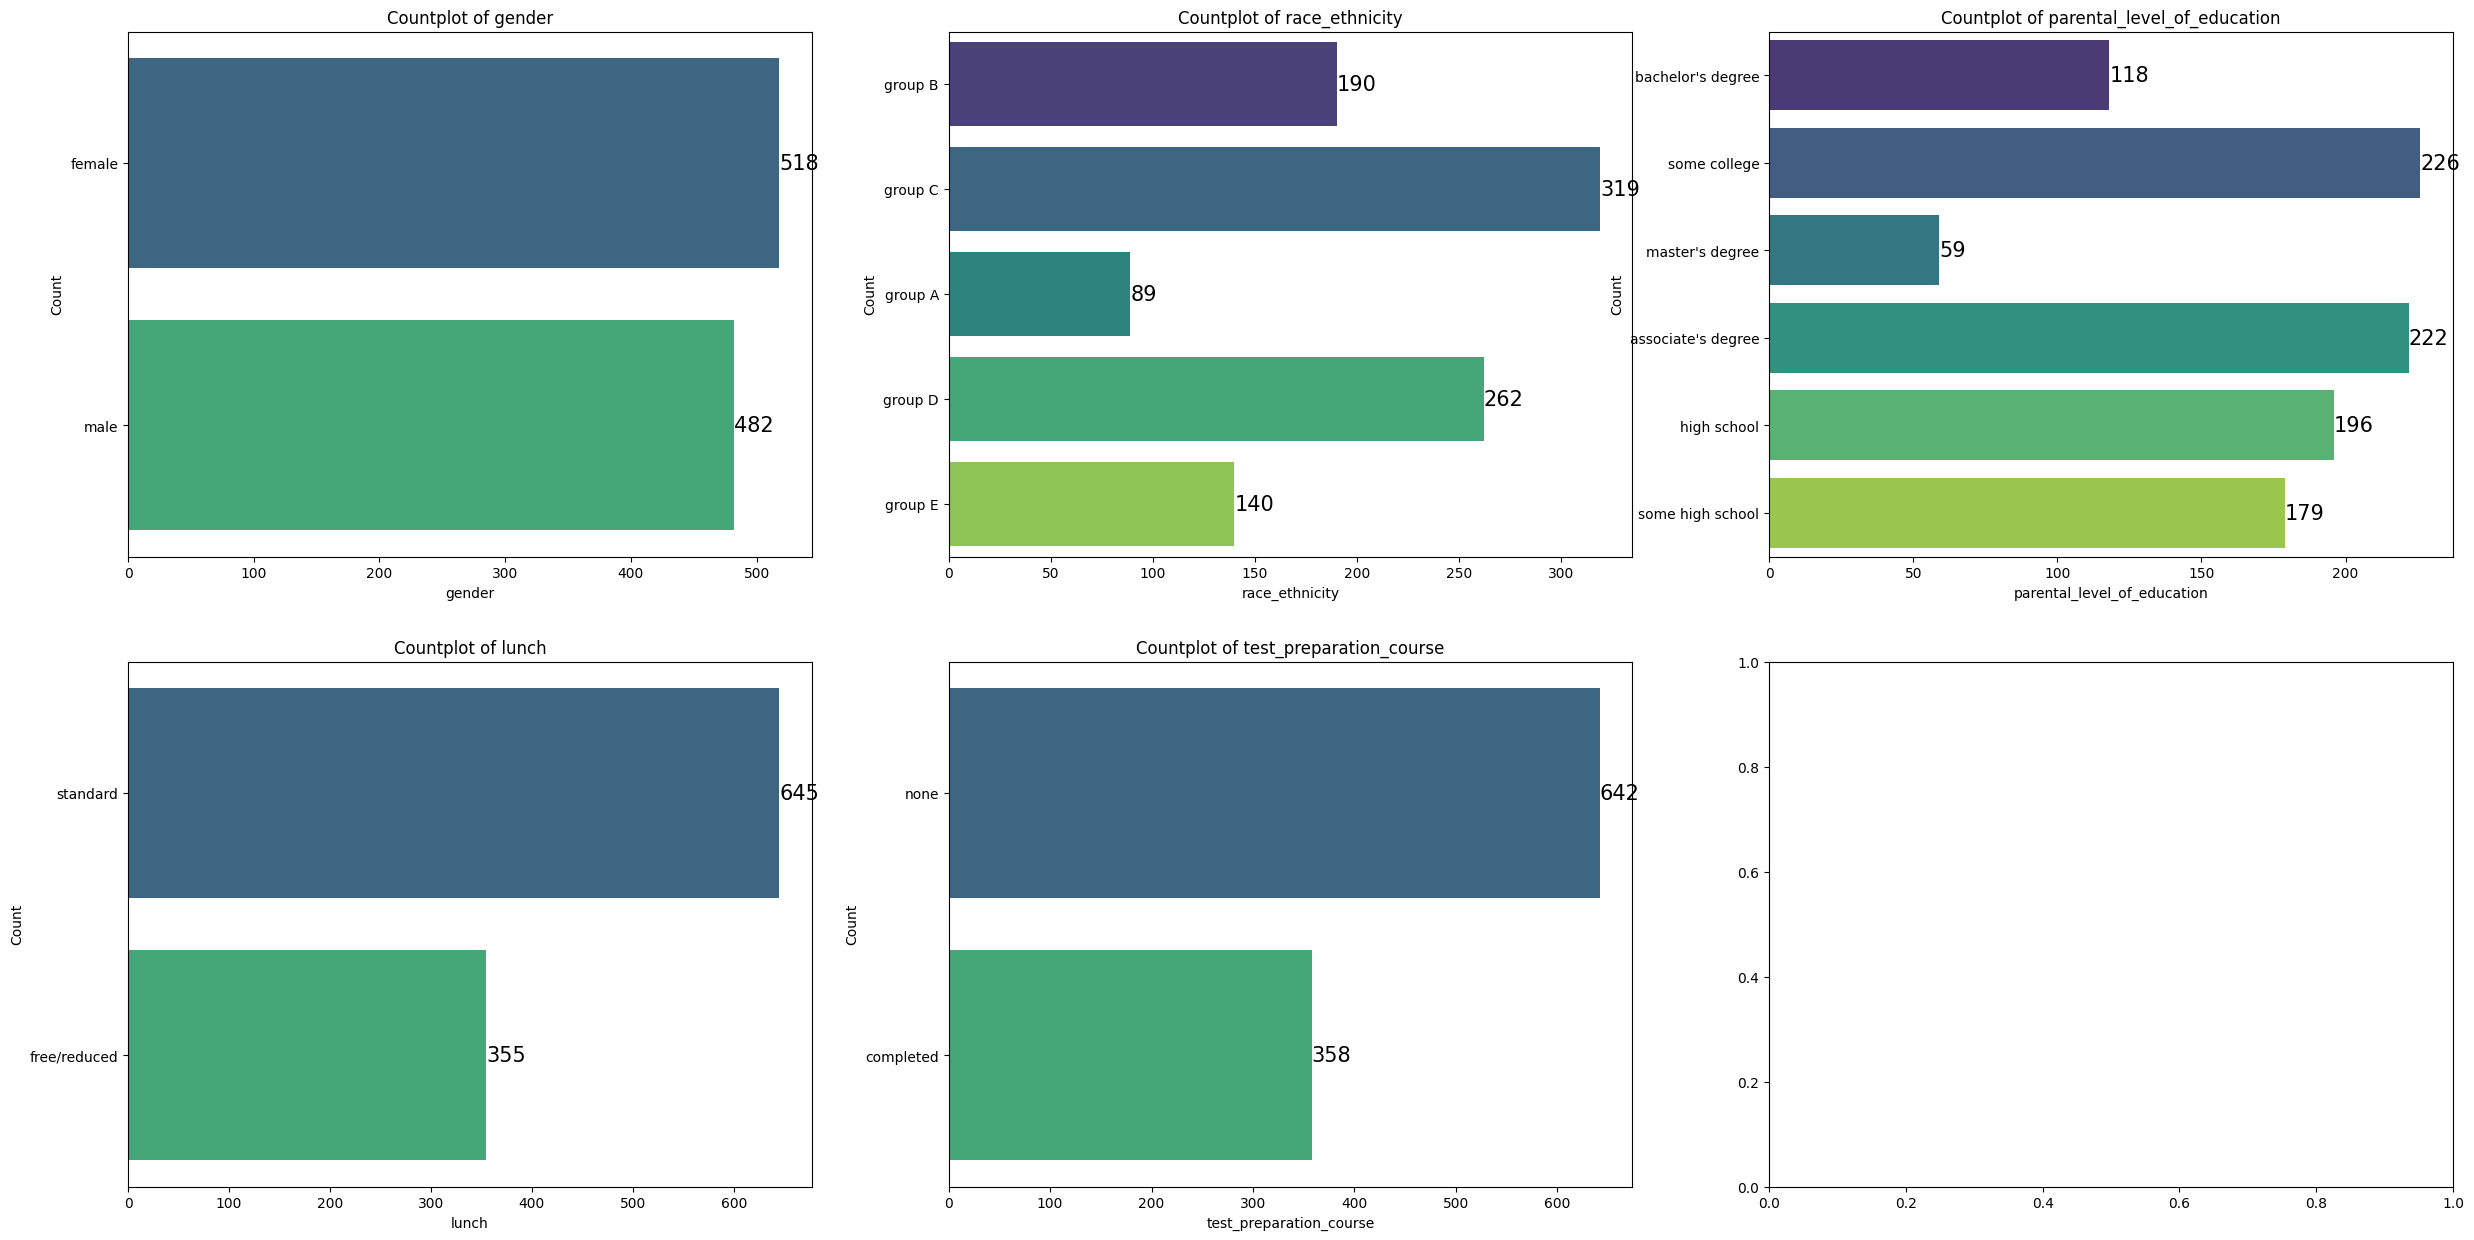

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(30, 15))
axes = axes.flatten()
for i, col in enumerate(cat_df.columns):
    sns.countplot(data=df, y=col, ax=axes[i],palette='viridis')
    axes[i].set_title(f"Countplot of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

    for container in axes[i].containers:
        axes[i].bar_label(container, color='black', size=15)



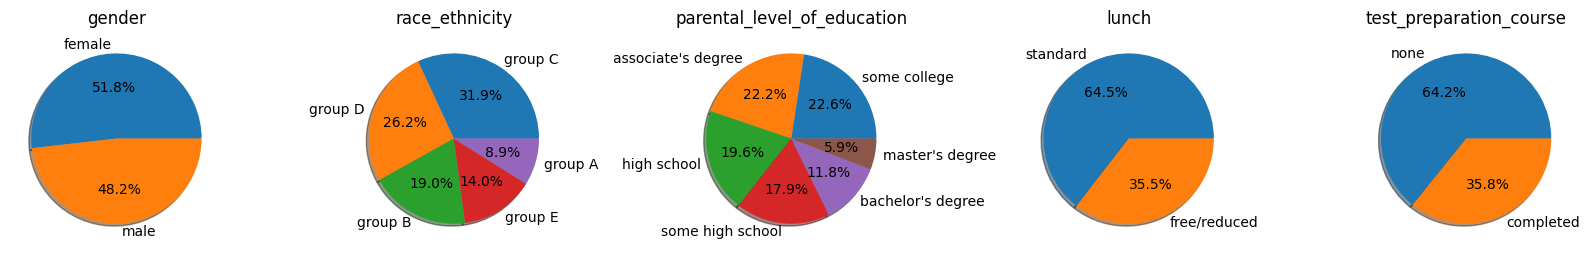

In [119]:
import matplotlib.pyplot as plt

# 1. Setup the figure and axes
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
axes = axes.flatten()

# 2. Loop through columns using enumerate to track the index
for i, col in enumerate(cat_df.columns):
    
    # Calculate counts once to make the code cleaner
    counts = df[col].value_counts()
    
    # 3. Draw the pie chart ON the specific axis (axes[i])
    axes[i].pie(
        x=counts, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        shadow=True
    )
    
    # 4. (Highly Recommended) Add a title so you know which chart is which
    axes[i].set_title(col)

# Prevents labels from overlapping
plt.tight_layout() 
plt.show()

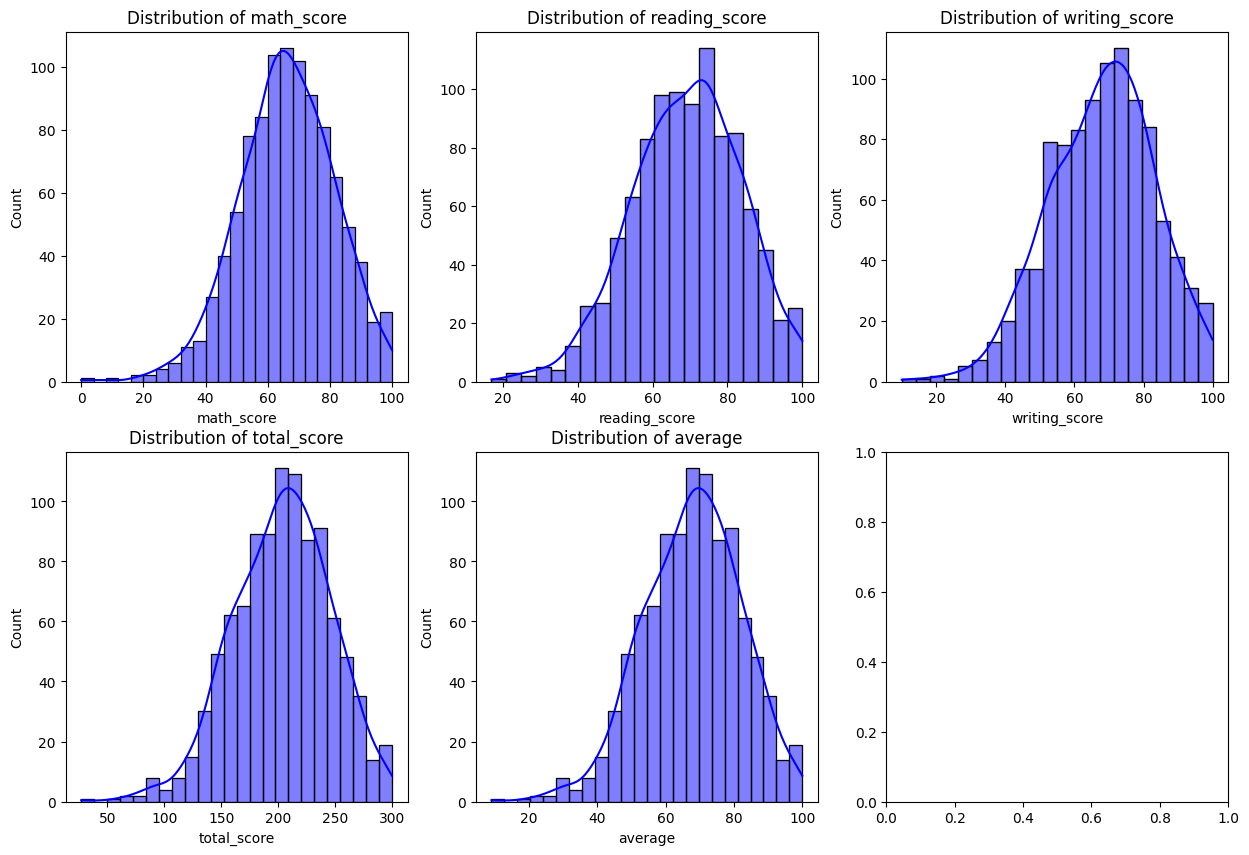

In [66]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

for col in numeric_df.columns:
    sns.histplot(data=df, x=col, ax=axes.flatten()[numeric_df.columns.get_loc(col)], kde=True, color='blue')
    axes.flatten()[numeric_df.columns.get_loc(col)].set_title(f"Distribution of {col}")
    axes.flatten()[numeric_df.columns.get_loc(col)].set_xlabel(col)
    axes.flatten()[numeric_df.columns.get_loc(col)].set_ylabel("Count")


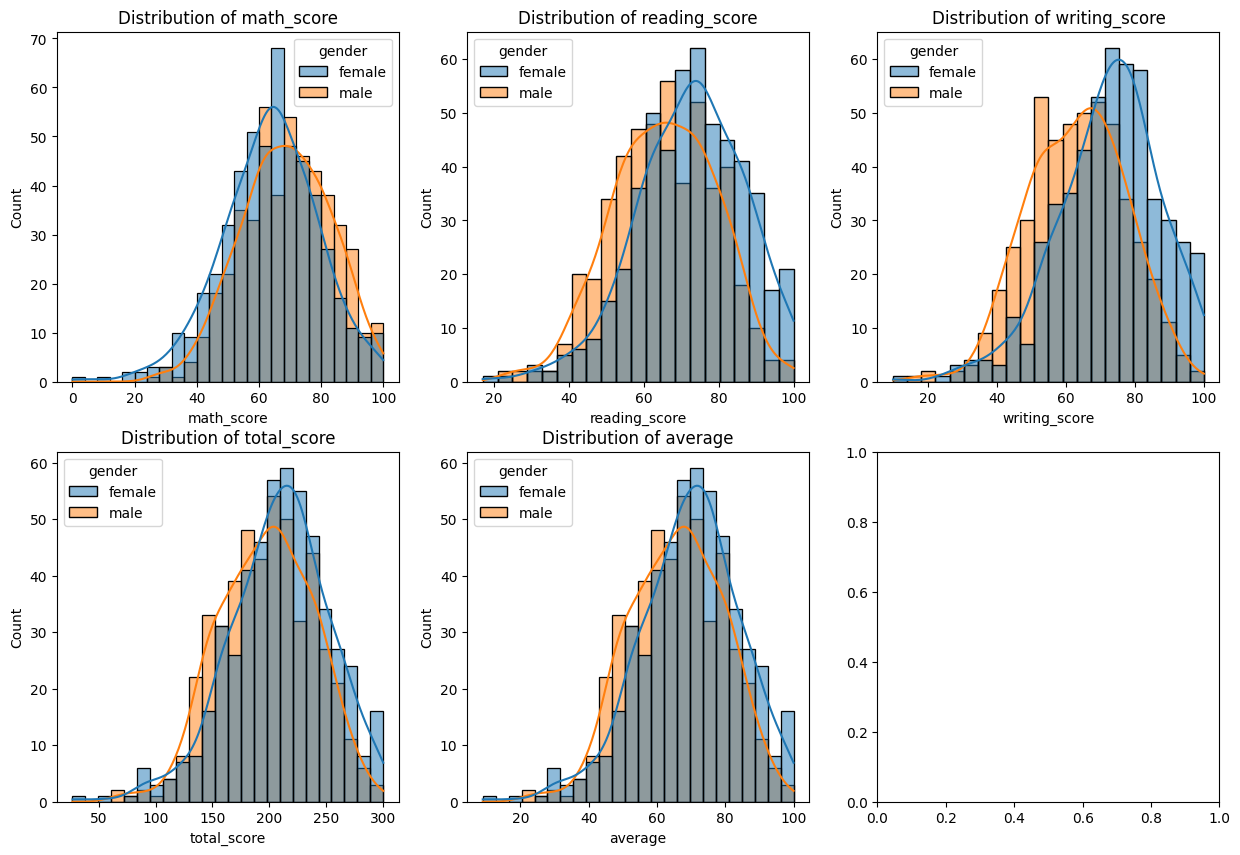

In [61]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))



for col in numeric_df.columns:
    sns.histplot(data=df, x=col, ax=axes.flatten()[numeric_df.columns.get_loc(col)],hue='gender', kde=True)
    axes.flatten()[numeric_df.columns.get_loc(col)].set_title(f"Distribution of {col}")
    axes.flatten()[numeric_df.columns.get_loc(col)].set_xlabel(col)
    axes.flatten()[numeric_df.columns.get_loc(col)].set_ylabel("Count")

<Axes: xlabel='gender'>

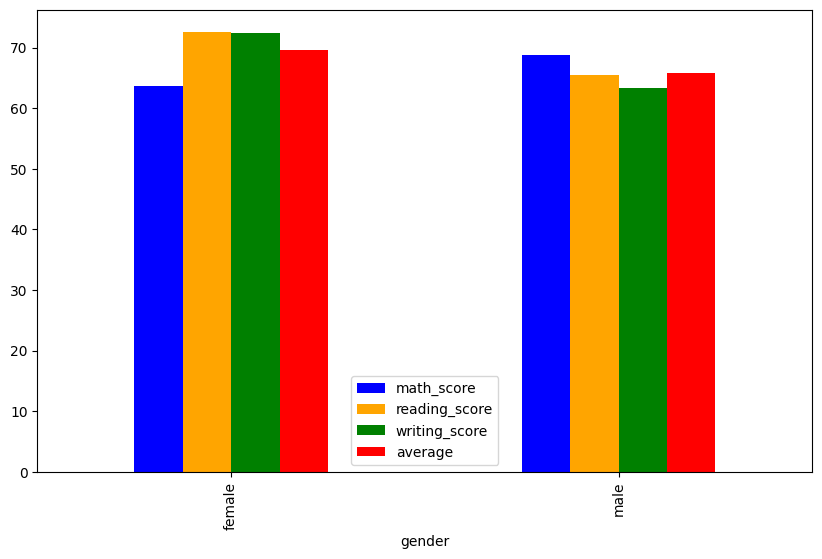

In [ ]:
df.groupby('gender')\
    .agg({'math_score':'mean',
            'reading_score':'mean',
            'writing_score':'mean',
            'average':'mean'})\
    .plot(kind='bar',figsize=(10,6),color=['blue','orange','green','red','purple'])



In [67]:
cat_df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')

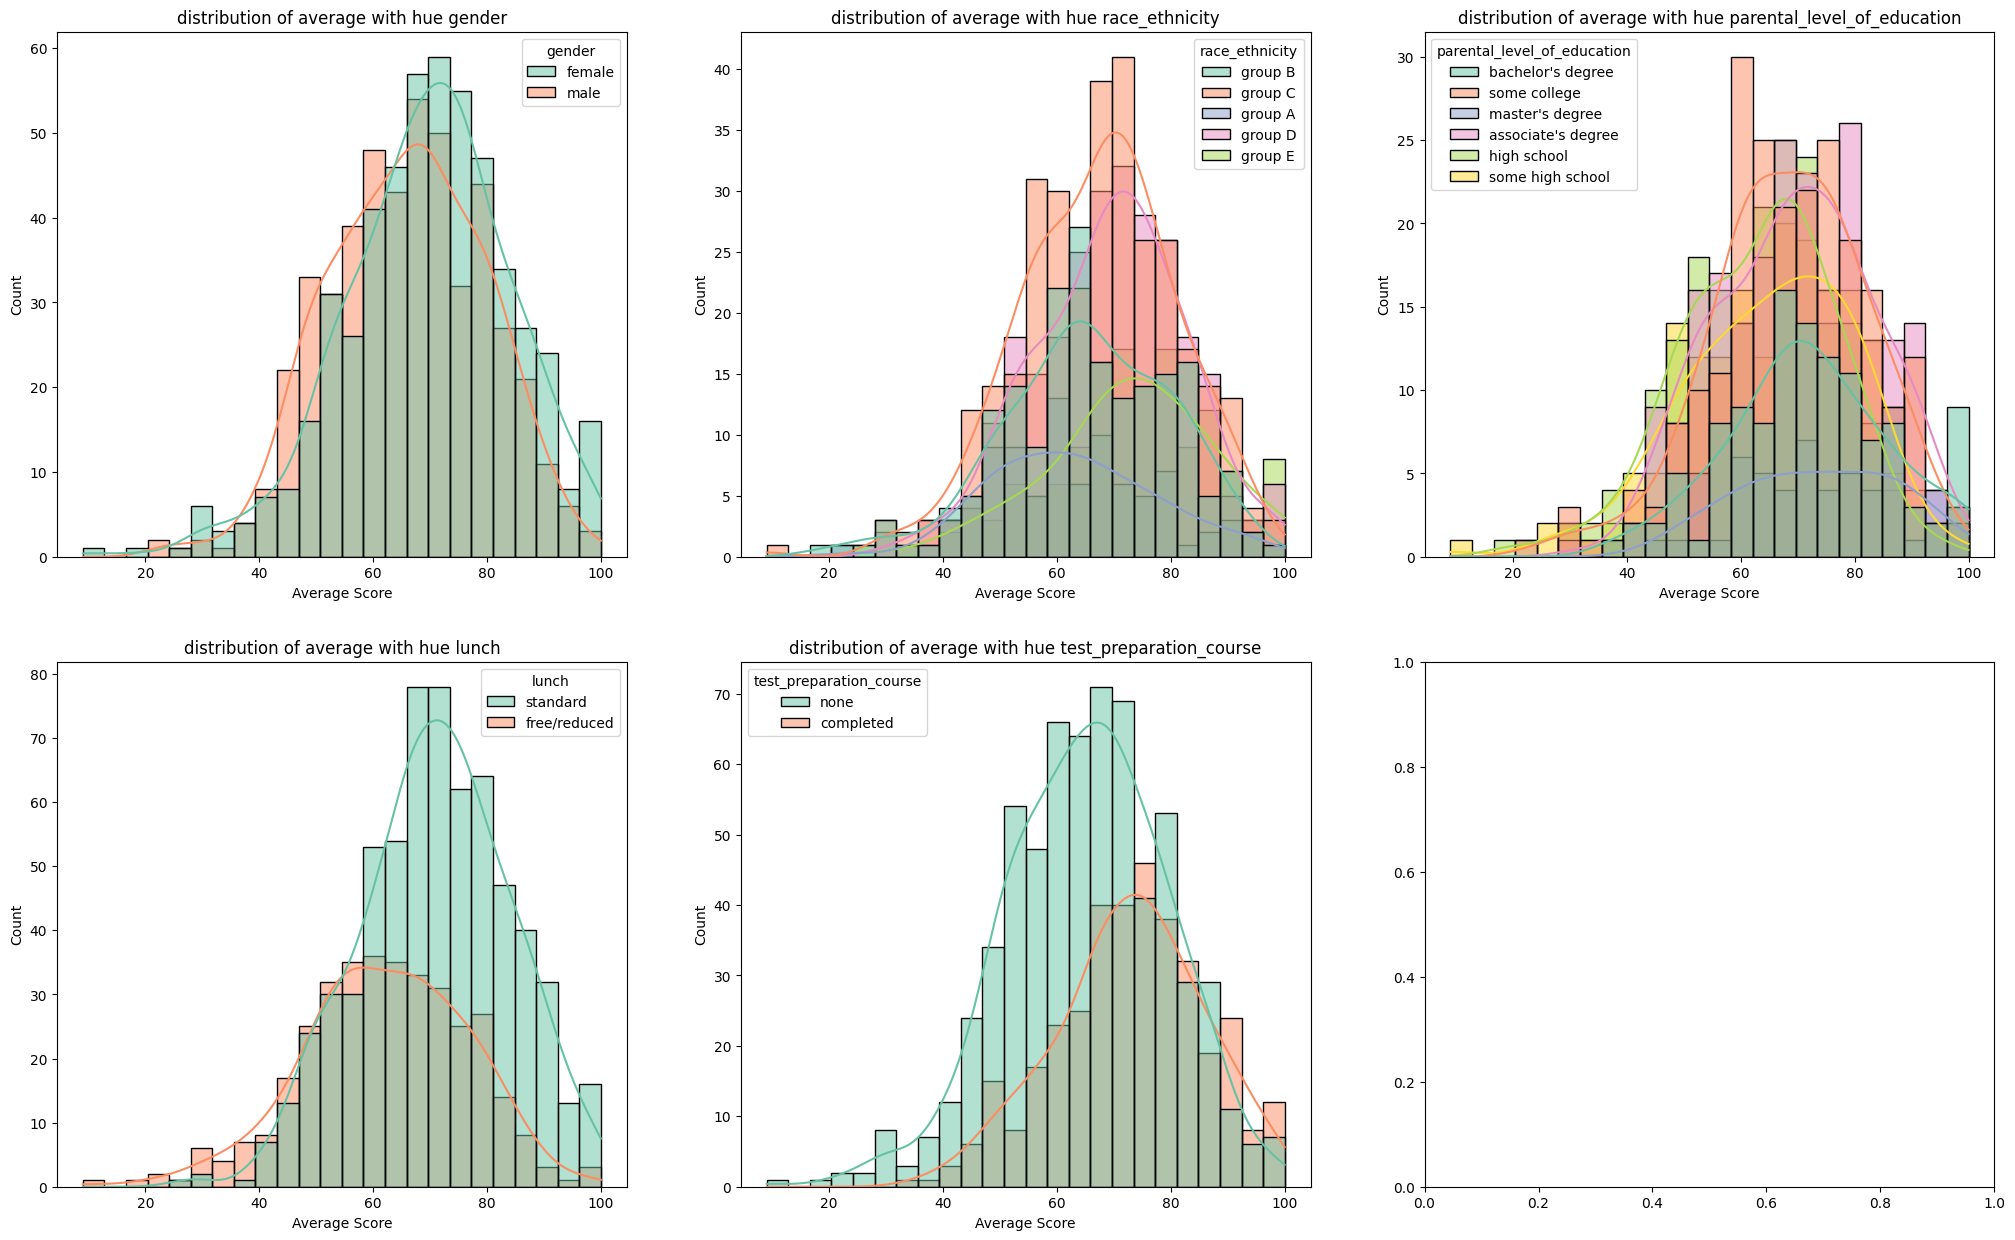

In [83]:
fig, axes = plt.subplots(2,3, figsize=(25, 15))
axes = axes.flatten()

for col in cat_df.columns:
    sns.histplot(data=df, x='average', hue=col, ax=axes[cat_df.columns.get_loc(col)], kde=True, palette='Set2')
    axes[cat_df.columns.get_loc(col)].set_title(f"distribution of average with hue {col}")
    axes[cat_df.columns.get_loc(col)].set_xlabel("Average Score")
    axes[cat_df.columns.get_loc(col)].set_ylabel("Count")


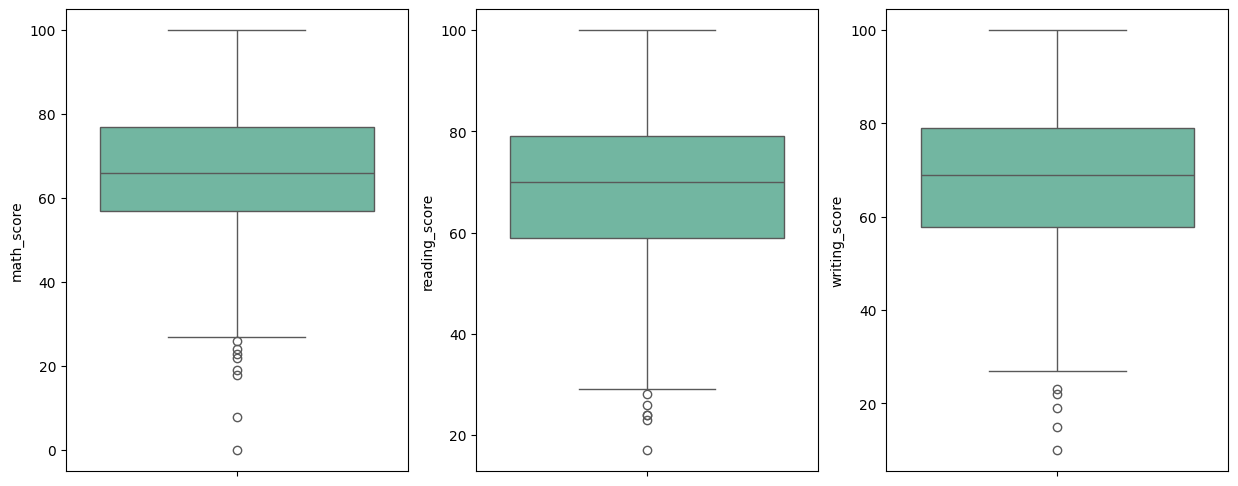

In [101]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

for col in ['math_score', 'reading_score', 'writing_score']:
    sns.boxplot(data=df, y= col, ax=axes[numeric_df.columns.get_loc(col)],palette='Set2')

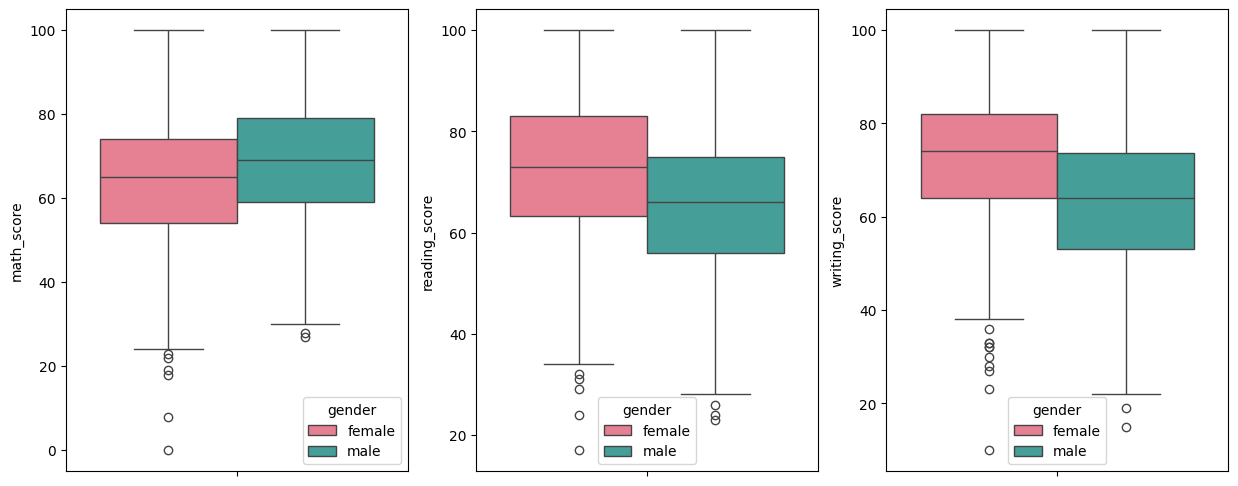

In [102]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

for col in ['math_score', 'reading_score', 'writing_score']:
    sns.boxplot(data=df, y= col, hue='gender', ax=axes[numeric_df.columns.get_loc(col)], palette='husl')
    

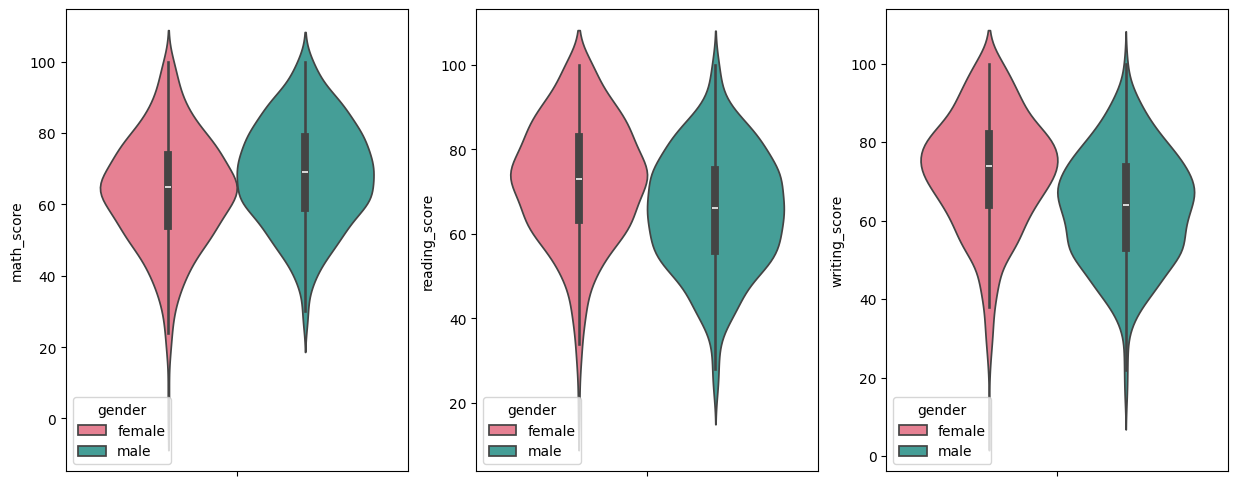

In [104]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

for col in ['math_score', 'reading_score', 'writing_score']:
    sns.violinplot(data=df, y= col, hue='gender', ax=axes[numeric_df.columns.get_loc(col)], palette='husl')
    

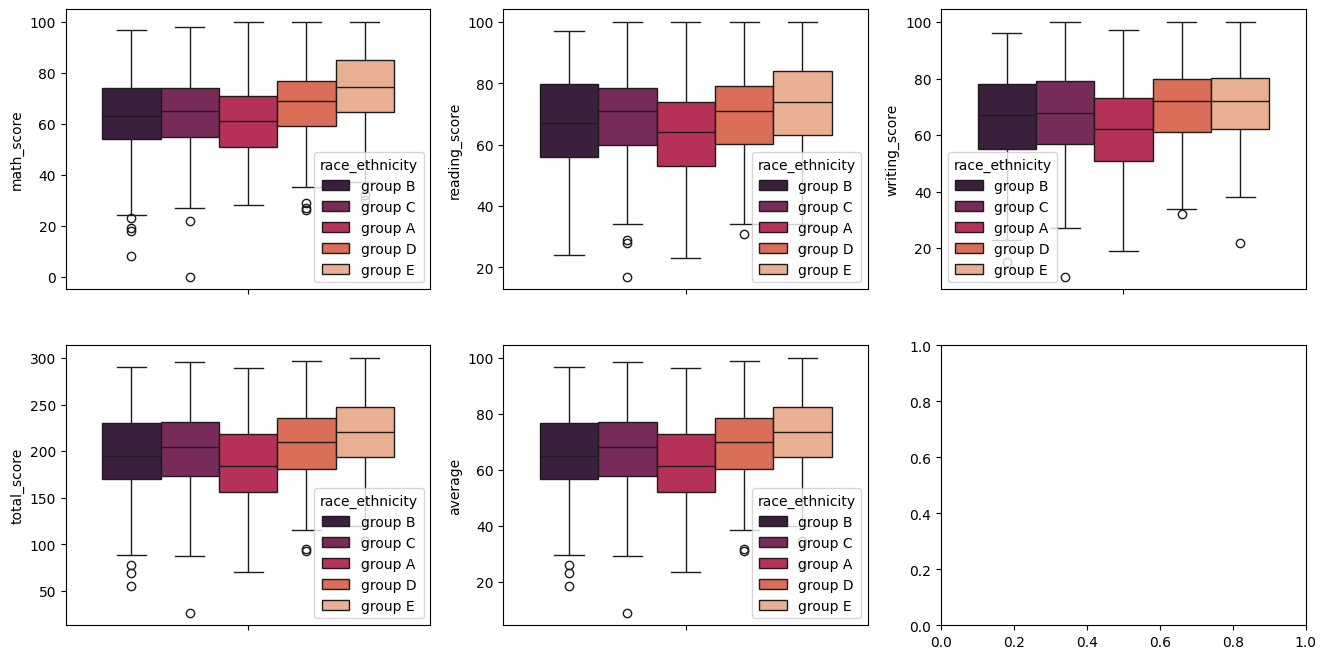

In [141]:
fig, axes = plt.subplots(2,3,figsize=(16,8))
axes = axes.flatten()
for col in numeric_df.columns:
    sns.boxplot(data=df, y=col, hue='race_ethnicity', ax=axes[numeric_df.columns.get_loc(col)], palette='rocket')
    

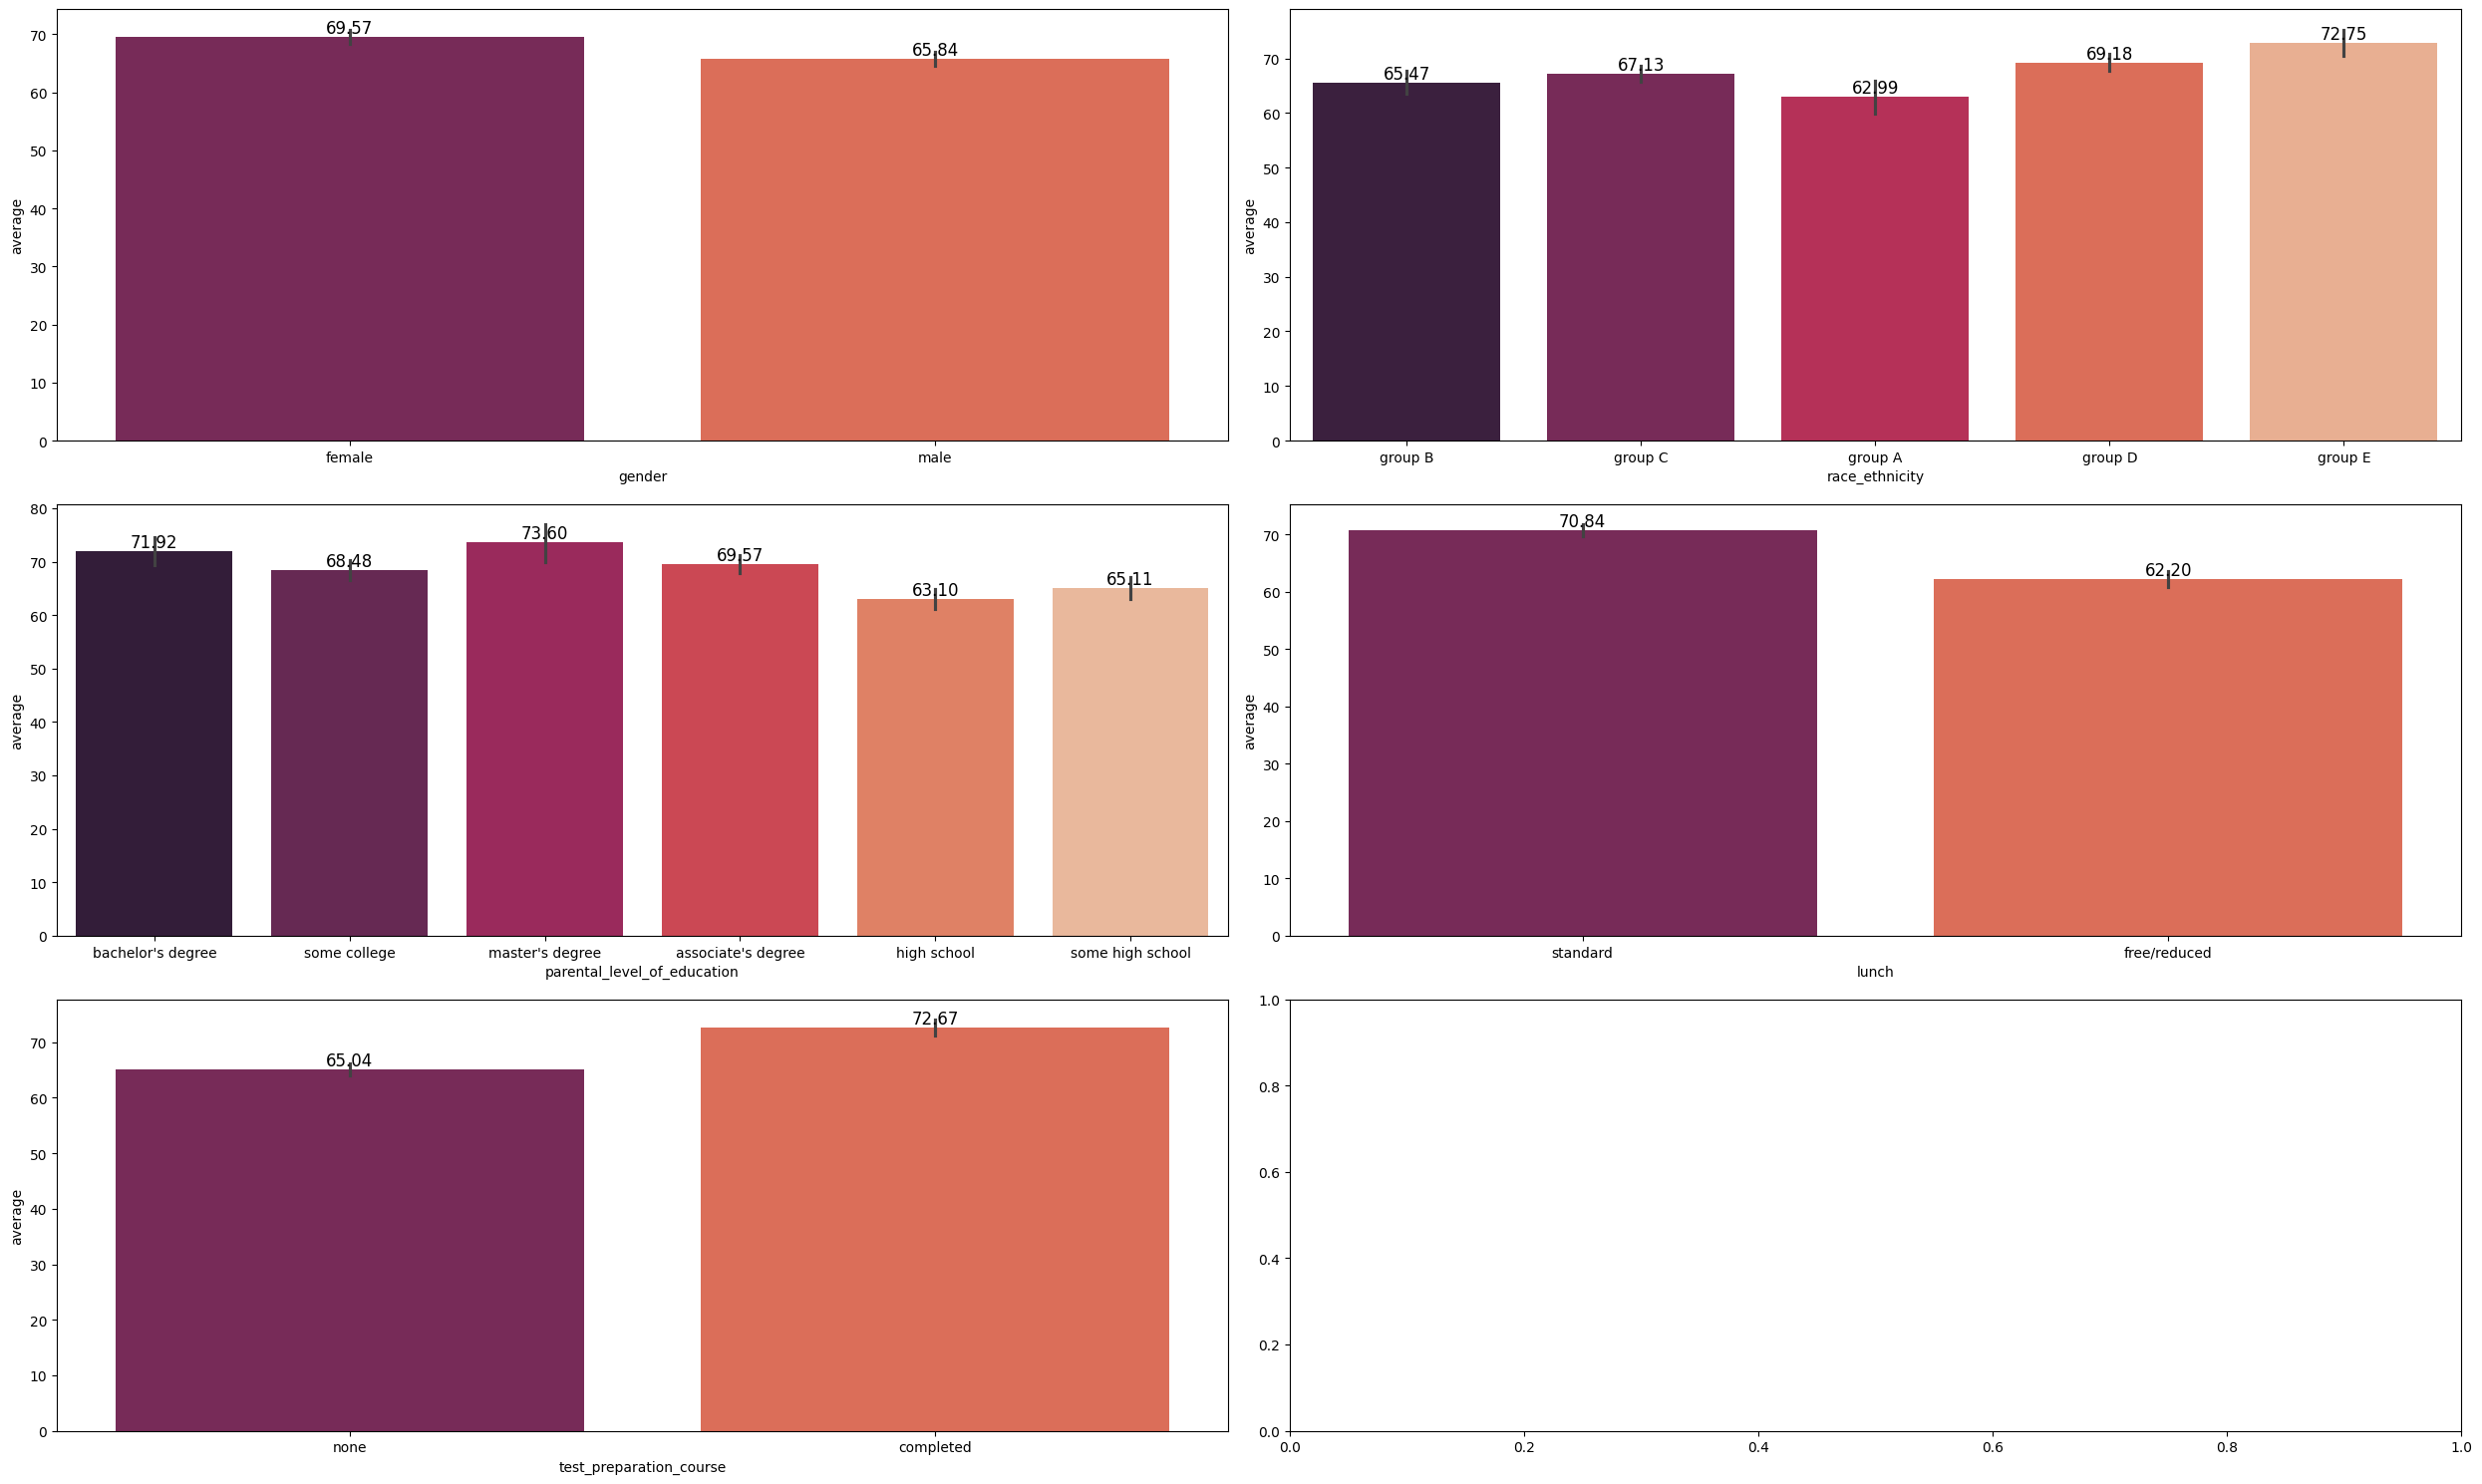

In [140]:
fig, axes = plt.subplots(3,2,figsize=(25,15))

axes = axes.flatten()
for i,col in enumerate(cat_df.columns):
    sns.barplot(data=df, x=col, y='average', ax=axes[i], palette='rocket')

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f', color='black', size=12)

plt.tight_layout()
plt.show()

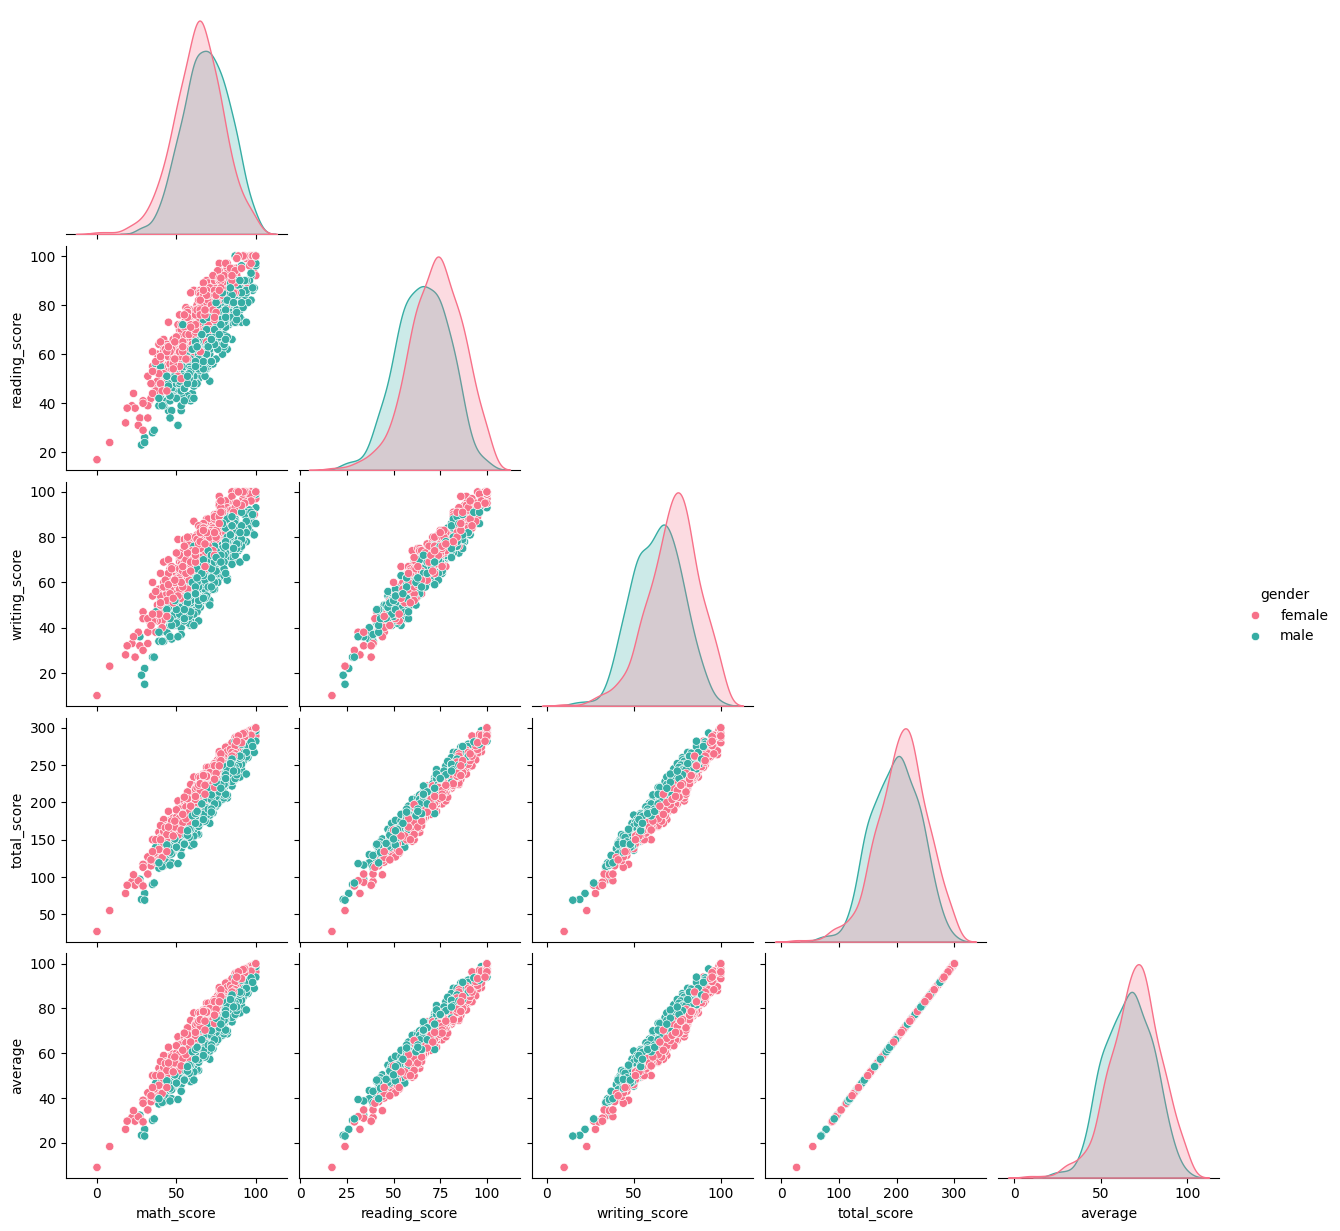

In [ ]:
sns.pairplot(df, hue='gender',palette='husl',diag_kmeanind='kde',corner=True)

In [142]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [143]:
df.drop(['total_score','average'],axis=1,inplace=True)

In [144]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [145]:
df.to_csv('data/preprocessed_student_data.csv',index=False)